<a href="https://colab.research.google.com/github/Dulyana-Silva/MLproject5-House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Dependencies

In [61]:
# mounting with google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error

Data Collection & Processing

In [63]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# Size of the dataset
df.shape

(20640, 10)

Exploratory Data Analysis (EDA)

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Column details**

1. **longitude**: A measure of how far west a house is; a higher value is farther west

2. **latitude**: A measure of how far north a house is; a higher value is farther north

3. **housingMedianAge**: Median age of a house within a block; a lower number is a newer building

4. **totalRooms**: Total number of rooms within a block

5. **totalBedrooms**: Total number of bedrooms within a block

6. **population**: Total number of people residing within a block

7. **households**: Total number of households, a group of people residing within a home unit, for a block

8. **medianIncome**: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. **medianHouseValue**: Median house value for households within a block (measured in US Dollars)

10. **oceanProximity**: Location of the house w.r.t ocean/sea

In [7]:
# Basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
target_col = "median_house_value"
num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
cat_cols = df.select_dtypes(include = ["object"]).columns.tolist()

print("Target column: ", target_col)
print("Numerical columns: ", num_cols)
print("Categorical columns: ", cat_cols)

Target column:  median_house_value
Numerical columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns:  ['ocean_proximity']


In [9]:
# Missing values analysis
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [10]:
# Check presence of encoded missing values
for col in df.columns:
  print(df[col].value_counts().head(20))

longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
-118.28    141
-118.35    140
-118.36    138
-118.19    135
-118.25    128
-118.37    128
-118.20    126
-118.14    125
-118.26    121
-118.13    121
-118.18    120
-118.34    119
-118.21    118
-118.15    116
-118.12    112
Name: count, dtype: int64
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
34.09    212
34.02    208
34.10    203
34.03    193
33.93    181
33.94    175
33.97    172
33.99    168
33.88    164
33.98    162
34.11    162
34.16    159
34.12    158
34.15    157
34.01    156
Name: count, dtype: int64
housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
Name: count, dtype: int64
total_rooms
1527.0    18
1613.0    17
1582.0    17
2127.0    16


Shows if there's any place holder value that has been encoded as missing value.
(Placeholders has been used for Missing values)

In this case --> total_bedrooms has missing values.

To handle --> Replace them in both training and test data with **Median** value in training data. (So it will avoid **data leakage**)

In [11]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# (If present --> drop those duplicates)
# df = df.drop_duplicates()
# print("Shape after dropping dulicates: ", df.shape)


Number of duplicate rows: 0


In [12]:
# Descriptive stat
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


Data Visualization

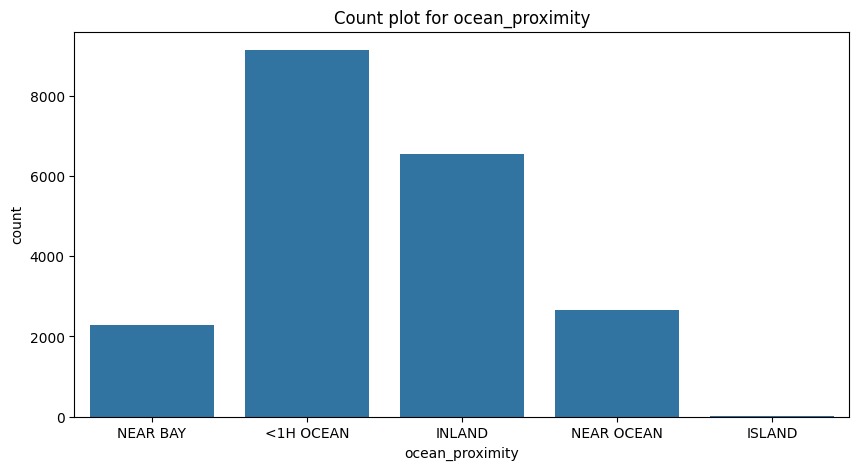

In [14]:
# countplot for categorical columns
for col in cat_cols:
  plt.figure(figsize = (10, 5))
  sns.countplot(data = df, x = col)
  plt.title(f"Count plot for {col}")
  plt.show()

In [15]:
for col in cat_cols:
  print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


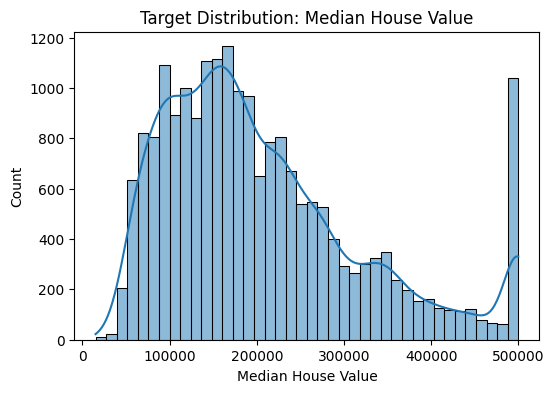

In [16]:
# target column distribution
plt.figure(figsize = (6,4))
sns.histplot(df[target_col], bins = 40, kde = True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

Here in plot, Maximum house price is 500,000 (because of that there's an abnormal peak at 500,000... All the upper values has gather there.)

In [17]:
df[target_col].value_counts()

# higher cap

,count
median_house_value,
500001.0,965
137500.0,122
162500.0,117
112500.0,103
187500.0,93
...,...
34200.0,1
46200.0,1
352000.0,1


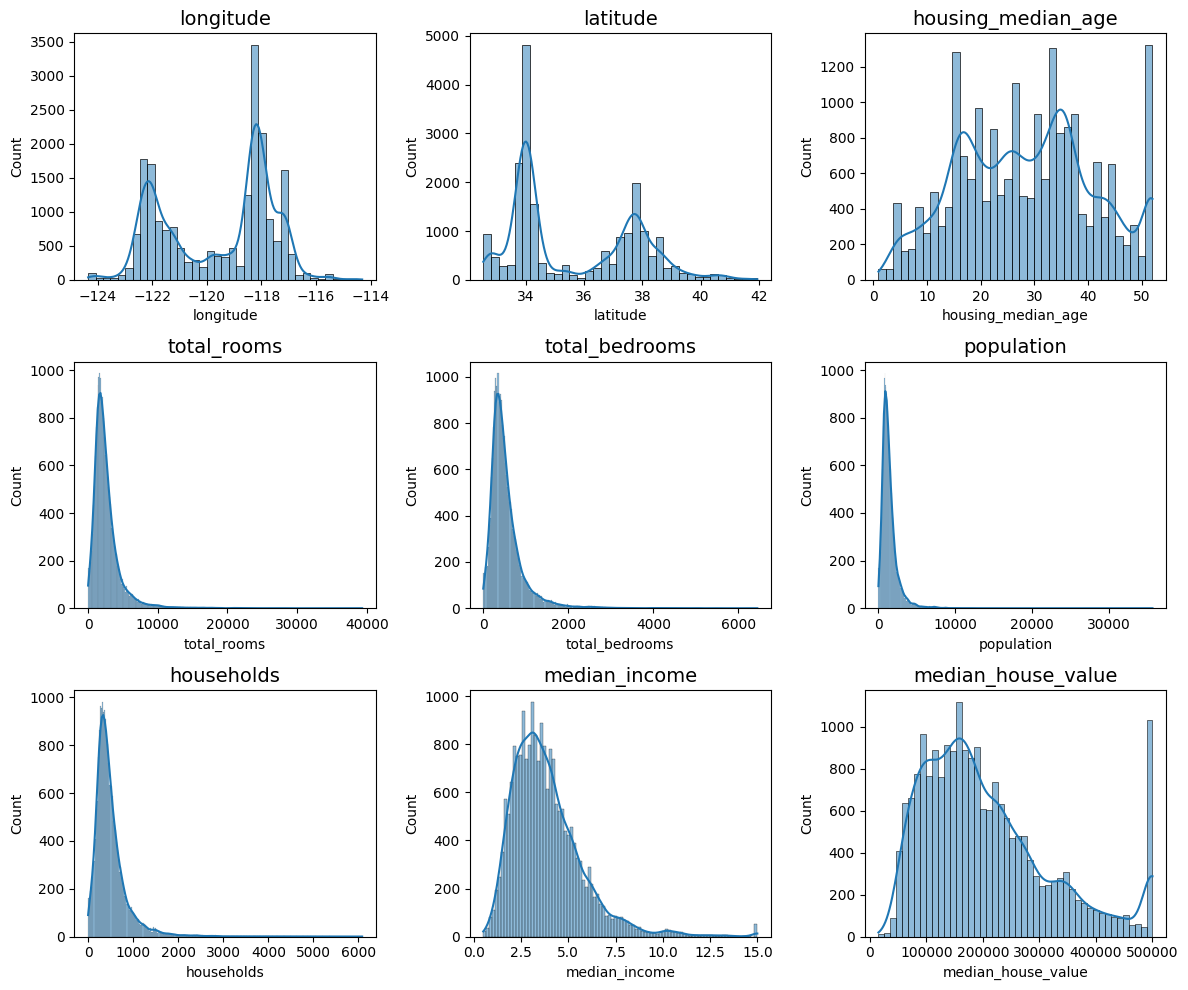

In [18]:
# histogram plot - distribution
fig, axes = plt.subplots(3,3 , figsize = (12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.histplot(df[col], ax = axes[i], kde = True)
  axes[i].set_title(col, fontsize= 14)

plt.tight_layout()
plt.show()

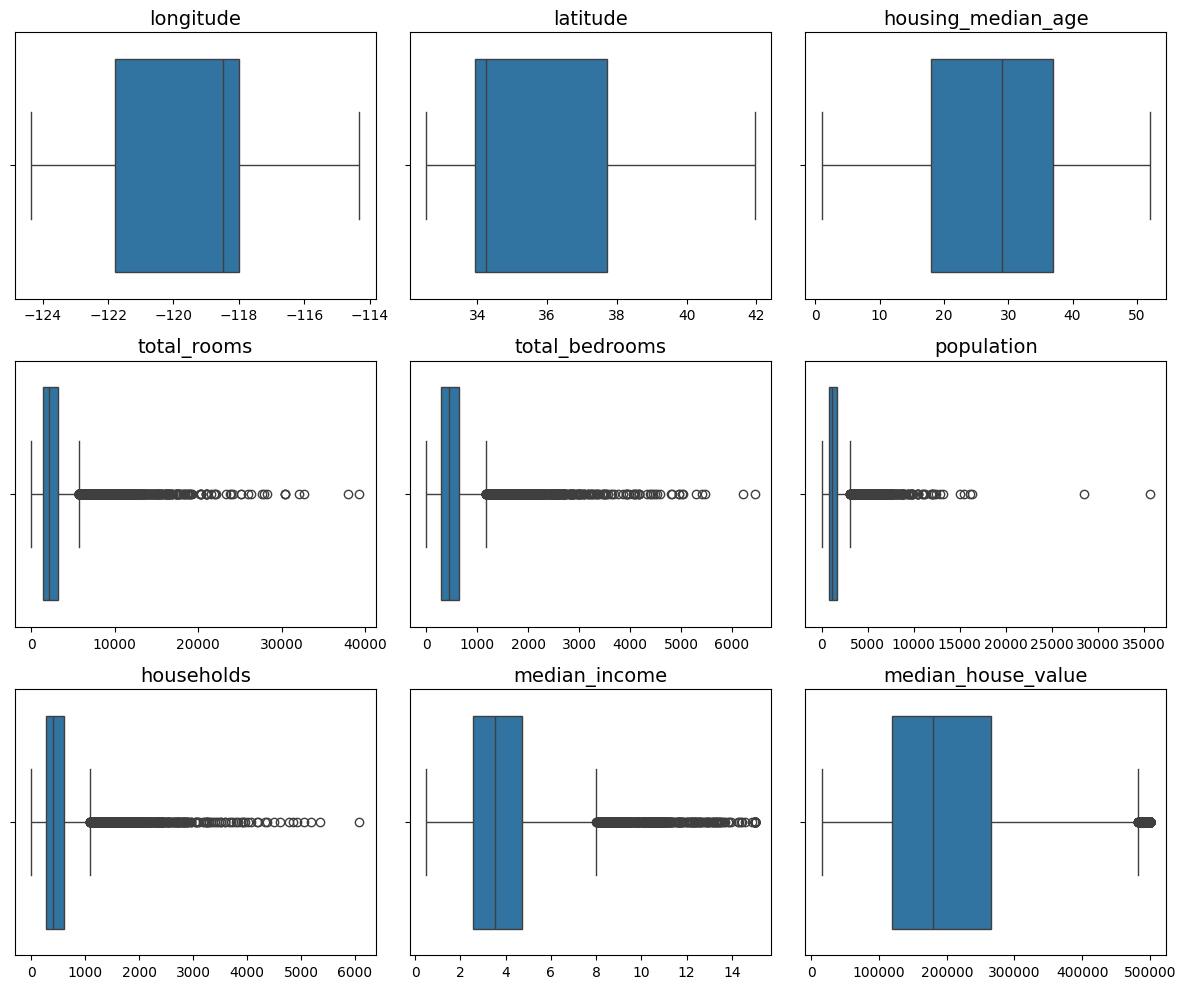

In [19]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3,3 , figsize = (12, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  sns.boxplot(x = df[col], ax = axes[i])
  axes[i].set_title(col, fontsize= 14)
  axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

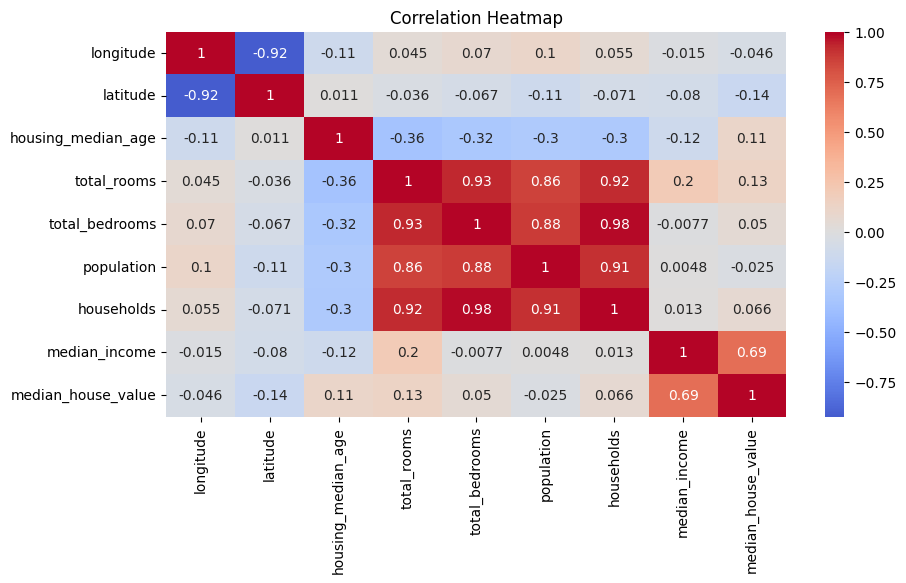

In [20]:
# identify presence of highly correlated columns & feature relationships.
plt.figure(figsize =[10, 5])
sns.heatmap(df[num_cols].corr(), annot = True, cmap = "coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [21]:
# correlation with target
corr_with_target = df[num_cols].corr()[target_col].sort_values(ascending = False)
print(corr_with_target)


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


Key Insights from EDA
-  Dataset has numeric + one categorical feature (Ocean_proximity)
-  Only total_bedrooms has missing values.
-  Target (median_house_value) is right-skewed and capped.
-  Several features show strong skew and outliers.
-  median_income is the strongest predictor.
-  High multicolinearity among room and population features.



Preprocessing & Evaluation Plan
-  Median imputation for missing values.
-  One-hot encoding for categorical features.
-  Feature scaling for liner models.
-  Use pipelines to avoid data leakage.
-  Baseline model --> CV model selection --> hyperparameter tuning.
-  Primary metric: RMSE, secondary: MAE and R^2.
-  Final evaluation only on test set.

Data Preprocessing

In [22]:
# Separate features & target
X = df.drop(columns= [target_col])
Y = df[target_col]

In [23]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [24]:
Y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [25]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state= 42)

In [26]:
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape:  (16512, 9)
Test shape:  (4128, 9)


Preproceessing Pipeline

In [27]:
numerical_features = X_train.select_dtypes(include = [np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include = ["object"]).columns.tolist()

print("Numerical features: ", numerical_features)
print("Categorical features: ", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy = "median")), ("scaler", StandardScaler())])

# categorical features - preprocessing steps
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy = "most_frequent")), ("encoder", OneHotEncoder(handle_unknown = "ignore"))])

# preprocessing pipeline
preprocess = ColumnTransformer(transformers=[("num", numerical_transformer, numerical_features), ("cat", categorical_transformer, categorical_features)])

Numerical features:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features:  ['ocean_proximity']


**When you have Ordinal category --> Lable encoding**
  -  a - 0
  -  b - 1
  -  c - 2

**When you have Nominal category (No Order) --> One-Hot encoding**
  -  a - 0 0 1
  -  b - 0 1 0
  -  c - 1 0 0






Baseline Model ---> No CV, No tuning

In [28]:
# Simple Linear Regression Model
baseline_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", LinearRegression())])

In [29]:
# Preprocess the data and train the baseline model
baseline_pipe.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

Evaluation of Baseline model

In [30]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [31]:
train_baseline_pred[:5]

array([188628.0772436 , 290379.8948687 , 250985.48476349, 146878.07878194,
       165789.41368924])

In [32]:
Y_train[:5]

,median_house_value
14196,103000.0
8267,382100.0
17445,172600.0
14265,93400.0
2271,96500.0


In [33]:
train_baseline_rmse = root_mean_squared_error(Y_train, train_baseline_pred)
train_baseline_mea = mean_absolute_error(Y_train, train_baseline_pred)
train_baseline_r2 = r2_score(Y_train, train_baseline_pred)

print("\n === Train Baseline Metrics (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse: .3f}")
print(f"MAE: {train_baseline_mea: .3f}")
print(f"R2:   {train_baseline_r2: .3f}")



 === Train Baseline Metrics (LinearRegression) ===
RMSE:  68433.937
MAE:  49594.842
R2:    0.650


RMSE, MAE always depend on the scale of target.

if the scale is in millions then erorr is smaller, but if the scale is in thousand then error is bigger.

In [34]:
test_baseline_rmse = root_mean_squared_error(Y_test, test_baseline_pred)
test_baseline_mea = mean_absolute_error(Y_test, test_baseline_pred)
test_baseline_r2 = r2_score(Y_test, test_baseline_pred)

print("\n === Test Baseline Metrics (LinearRegression) ===")
print("RMSE: ", test_baseline_rmse)
print("MAE: ", test_baseline_mea)
print("R2: ", test_baseline_r2)


 === Test Baseline Metrics (LinearRegression) ===
RMSE:  70059.19333925014
MAE:  50670.48923565361
R2:  0.6254382675296266


**Model Selection & *Optimization***

In [35]:
# Models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state = 42),
    "Lasso": Lasso(random_state = 42, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor()
}

In [36]:
# KFold value --> k -number of fold that we want
k = 5
cv = KFold(n_splits = k, shuffle = True, random_state = 42)

In [37]:
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [38]:
rows = []

for name, model in models.items():
  pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

  scores = cross_validate(pipe, X_train, Y_train, cv = cv, scoring = scoring, n_jobs =1)
  rows.append({
      "Model": name,
      "cv_RMSE": -scores["test_RMSE"].mean(),
      "cv_MAE": -scores["test_MAE"].mean(),
      "cv_R2": scores["test_R2"].mean()
  })

# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values(by = "cv_RMSE")
print("=== CV Model Comparison ===")
print(cv_results)




=== CV Model Comparison ===
                  Model       cv_RMSE        cv_MAE     cv_R2
4  HistGradientBoosting  48396.203131  32413.168596  0.824739
3          RandomForest  49378.373514  32234.807103  0.817573
1                 Ridge  68595.617399  49664.330927  0.647760
2                 Lasso  68603.233277  49667.262611  0.647685
0      LinearRegression  68604.162955  49667.159067  0.647676


In [39]:
scores

{'fit_time': array([0.75153399, 0.70883799, 0.71810126, 0.73342776, 0.81031656]),
 'score_time': array([0.05870175, 0.05820513, 0.05961657, 0.05962992, 0.22517586]),
 'test_RMSE': array([-49717.50122587, -48347.12830937, -47362.04414644, -49565.40791164,
        -46988.93406259]),
 'test_MAE': array([-33230.06987541, -32467.98642524, -31928.21856571, -32505.20222395,
        -31934.36588948]),
 'test_R2': array([0.82088031, 0.82403105, 0.83179487, 0.81763507, 0.82935507])}

In [40]:
rows

[{'Model': 'LinearRegression',
  'cv_RMSE': np.float64(68604.16295529754),
  'cv_MAE': np.float64(49667.15906724985),
  'cv_R2': np.float64(0.6476757451183028)},
 {'Model': 'Ridge',
  'cv_RMSE': np.float64(68595.61739914853),
  'cv_MAE': np.float64(49664.330927177056),
  'cv_R2': np.float64(0.6477600560394983)},
 {'Model': 'Lasso',
  'cv_RMSE': np.float64(68603.2332772403),
  'cv_MAE': np.float64(49667.26261132317),
  'cv_R2': np.float64(0.6476847875205972)},
 {'Model': 'RandomForest',
  'cv_RMSE': np.float64(49378.37351414261),
  'cv_MAE': np.float64(32234.807102504506),
  'cv_R2': np.float64(0.8175725121507972)},
 {'Model': 'HistGradientBoosting',
  'cv_RMSE': np.float64(48396.203131180395),
  'cv_MAE': np.float64(32413.168595957184),
  'cv_R2': np.float64(0.8247392727982465)}]

In [41]:
cv_results

,Model,cv_RMSE,cv_MAE,cv_R2
4,HistGradientBoosting,48396.203131,32413.168596,0.824739
3,RandomForest,49378.373514,32234.807103,0.817573
1,Ridge,68595.617399,49664.330927,0.647760
2,Lasso,68603.233277,49667.262611,0.647685
0,LinearRegression,68604.162955,49667.159067,0.647676


we can see, Gradient Boost got the lowest score.

R2 score higher --> better the model is, again it's Gradient Boost

 **So the Best model is, Hist Gradient Boosting.**

In [42]:
best_row = cv_results.sort_values(by = "cv_RMSE").iloc[0]

best_model_name = best_row["Model"]
best_rmse = best_row["cv_RMSE"]

print("Best model based on CV RMSE")
print("Best Model: ", best_model_name)
print("CV RMSE", best_rmse)

Best model based on CV RMSE
Best Model:  HistGradientBoosting
CV RMSE 48396.203131180395


**BEST MODEL: HistGradientBoostingRegressor**

Hyperparameter Tuning

In [43]:
hgb_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", HistGradientBoostingRegressor(random_state = 42))])

In [44]:
# hyperparameters combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [45]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

RandomSearch --> getting combinations of some random values.

GridSearch -->  getting all the combinations of values to perform.

In [46]:
# perform grid search
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [47]:
print("\n=== Tuned HistGB (CV)===")
print("Best CV RMSE:", -grid.best_score_)
print("Best paras:", grid.best_params_)


=== Tuned HistGB (CV)===
Best CV RMSE: 47408.38131673431
Best paras: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


**Retraining the model wth best params**

In [48]:
hgb_best = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization= 0.1,
            learning_rate = 0.1,
            max_depth = None,
            max_leaf_nodes = 63,
            min_samples_leaf = 20
        ))
    ]
)

In [50]:
grid.best_estimator_

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63,
                                               random_state=42))])

or another way --->

In [49]:
# train best model on entire training data  (can also be done ith refit=True in grid search)
hgb_best.fit(X_train, Y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

Final Evaluation

In [52]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(Y_train, train_final_pred)
train_final_mae = mean_absolute_error(Y_train, train_final_pred)
train_final_r2 = r2_score(Y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse: .3f}")
print(f"MAE: {train_final_mae: .3f}")
print(f"R2: {train_final_r2: .3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE:  35665.412
MAE:  24312.911
R2:  0.905


In [54]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(Y_test, test_final_pred)
test_final_mae = mean_absolute_error(Y_test, test_final_pred)
test_final_r2 = r2_score(Y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse: .3f}")
print(f"MAE: {test_final_mae: .3f}")
print(f"R2: {test_final_r2: .3f}")


=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE:  46204.746
MAE:  30548.664
R2:  0.837


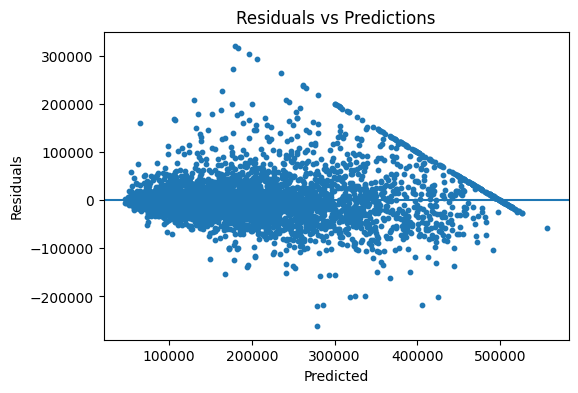

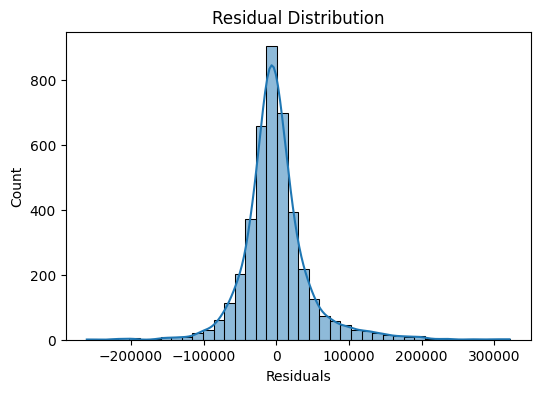

In [55]:
# Residual plot

residuals = Y_test - test_final_pred

plt.figure(figsize =(6,4))
plt.scatter(test_final_pred, residuals, s= 10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins= 40, kde= True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()


**1st plot**
-  Each dot represent a house.
-  plt.axhline(0) ---> to get the horizontal line.


**2nd plot**
-  Most values are concentrated in the center.

**Building a predictive system**

In [69]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:


    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).

    """

    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [71]:
# Example inference
example_pred = predict_house_price(
    model= hgb_best,
    longitude= 122.230,
    latitude= 37.880,
    housing_median_age= 41,
    total_rooms= 880,
    total_bedrooms= 129,
    population= 322,
    households= 126,
    median_income= 8.3252,
    ocean_proximity= "NEAR BAY"
)

print("\nExample prediction: ", round(example_pred, 2))


Example prediction:  308249.68
